<a href="https://colab.research.google.com/github/varunchaturmutha/Electricity-Usage-Prediction/blob/main/Electricity_Grid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Series Forecasting with Machine Learning

Using Machine Learning to Forecast Energy Consumption.

Data can be found here: https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption

In [111]:
from google.colab import drive
drive.mount('/content/drive')#/MyDrive/data_science_projects')#/electricity_usage_prediction/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [112]:
#Importing relevant packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.metrics import mean_squared_error
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

- Loading hourly energy consumption data from American Electric Power (AEP).
- Convert megawatt to gigawatt to reduce number significant digits.
- Sort the data by time.

In [113]:
df = pd.read_csv('./drive/MyDrive/data_science_projects/electricity_usage_prediction/PJME_hourly.csv')
# df = pd.read_csv('sample_data/AEP_hourly.csv')
provider = 'PJME' #'AEP'
MW = f'{provider}_MW'
GW = f'{provider}_GW'
df[GW] = df[MW] / 1e3
df = df.set_index('Datetime')
df.index = pd.to_datetime(df.index)
df = df.sort_values(by='Datetime')
df = df.drop(columns=[MW])
display(df)

,PJME_GW
Datetime,
2002-01-01 01:00:00,30.393
2002-01-01 02:00:00,29.265
2002-01-01 03:00:00,28.357
2002-01-01 04:00:00,27.899
2002-01-01 05:00:00,28.057
...,...
2018-08-02 20:00:00,44.057
2018-08-02 21:00:00,43.256
2018-08-02 22:00:00,41.552


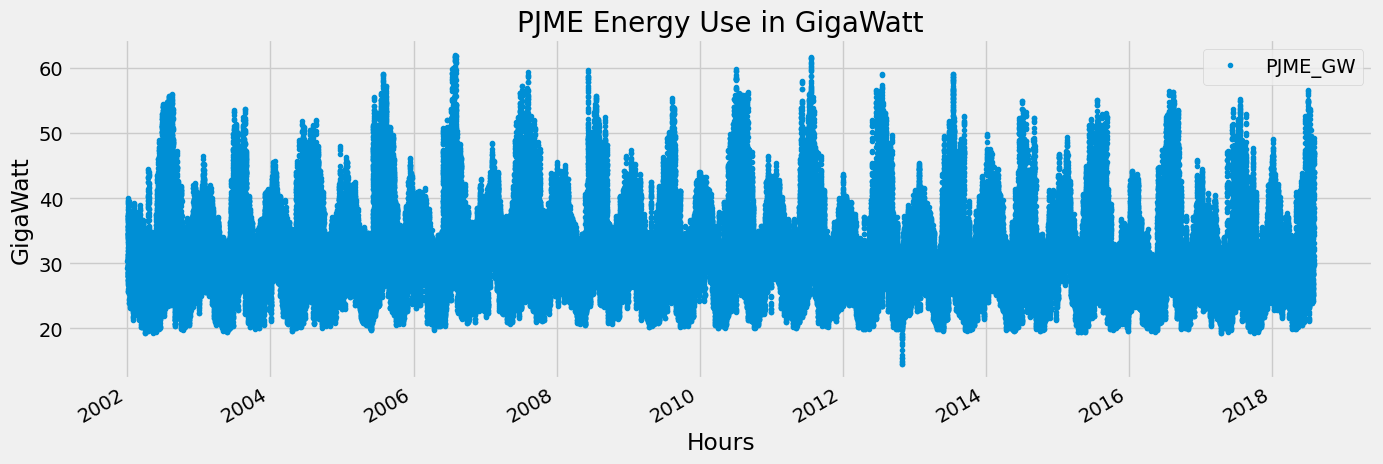

In [114]:
df.plot(style='.',
        figsize=(15, 5),
        color=color_pal[0],
        xlabel='Hours',
        ylabel='GigaWatt',
        title=f'{provider} Energy Use in GigaWatt')
plt.show()


# Train / Test Split

Split the train / test data into 80:20 ratio.

In [115]:
ind_test = int(len(df) * 0.80)
test_end_date = df.index[ind_test]
print(f"{'Dataset Start Date:':<20} {df.index[0]}")
print(f"{'Train Set End Date:':<20} {test_end_date}")
print(f"{'Dataset End Date:':<20} {df.index[-1]}")

Dataset Start Date:  2002-01-01 01:00:00
Train Set End Date:  2015-04-09 15:00:00
Dataset End Date:    2018-08-03 00:00:00


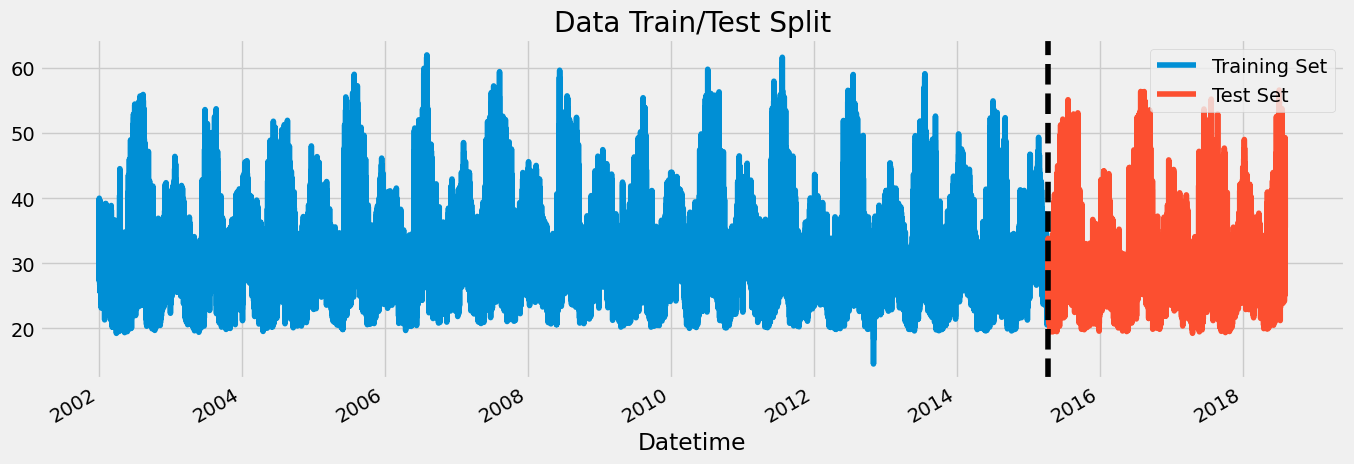

In [116]:
train = df.loc[df.index < test_end_date]
test = df.loc[df.index >= test_end_date]

fig, ax = plt.subplots(figsize=(15, 5))
train.plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test.plot(ax=ax, label='Test Set')
ax.axvline(test_end_date, color='black', ls='--')
ax.legend(['Training Set', 'Test Set'])
plt.show()

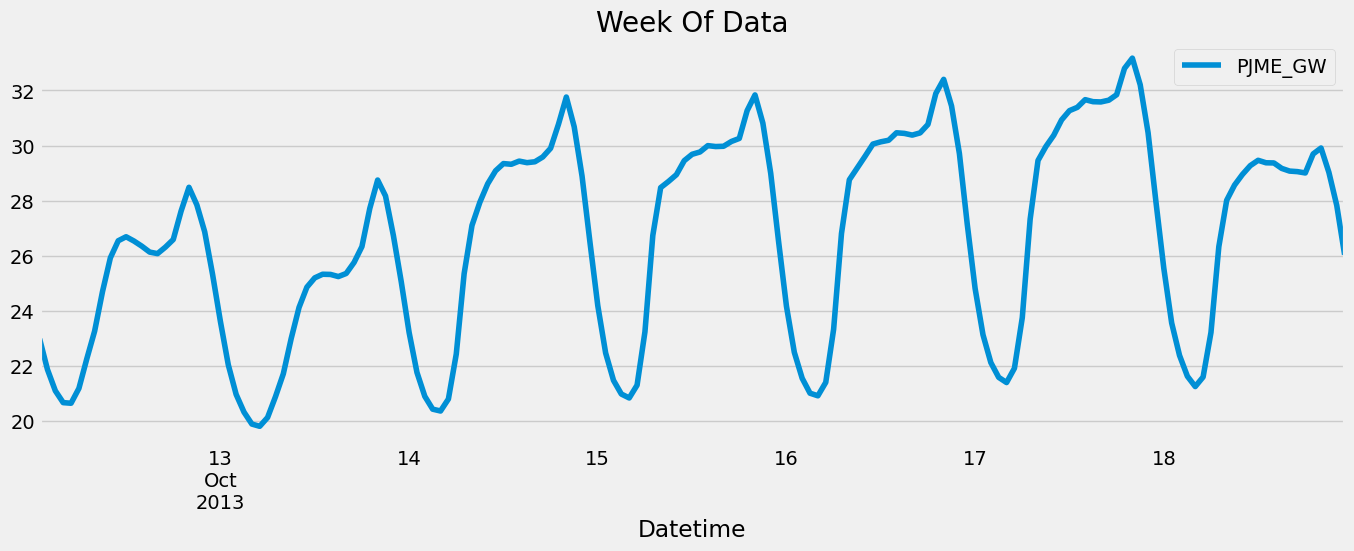

In [117]:
df_crop = df.loc[(df.index > '10-12-2013') & (df.index < '10-19-2013')]
df_crop.plot(figsize=(15, 5), title='Week Of Data')
plt.show()

# Feature Creation

In [118]:
def create_features(df):
    """
    Create time series features based on time series index.
    Hour, dayofweek, quarter, month, year, dayofyear, dayofmonth, weekofyear.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['dayname'] = df.index.day_name()
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

df = create_features(df)

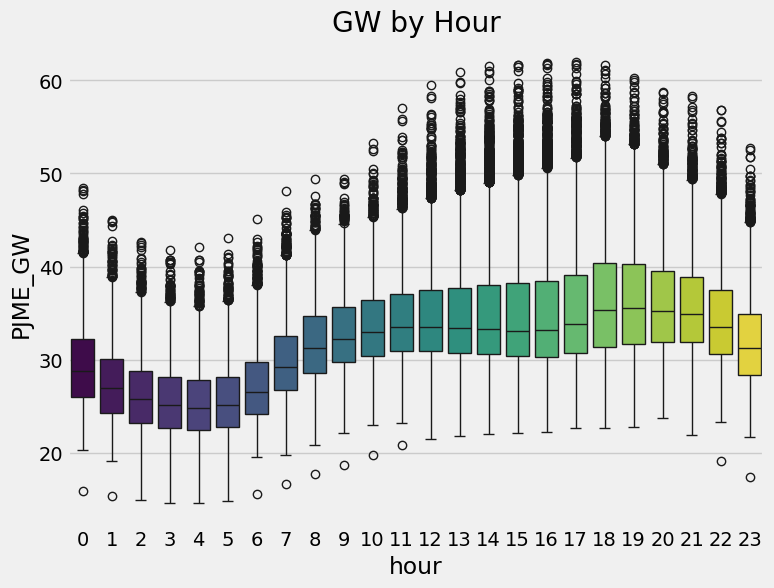

In [119]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x='hour', y=f'{provider}_GW', hue='hour', palette='viridis', legend=False)
ax.set_title('GW by Hour')
plt.show()

The outlier circles in the plot above are points that stay out of the interval [Q1-1.5*IQR; Q3+1.5*IQR], with:

Q1 = Quartile 1 (25th percentile)

Q3 = Quartile 3 (75th percentile)

IQR = Interquartile range from Q1 to Q3

/tmp/ipykernel_189/4203917940.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


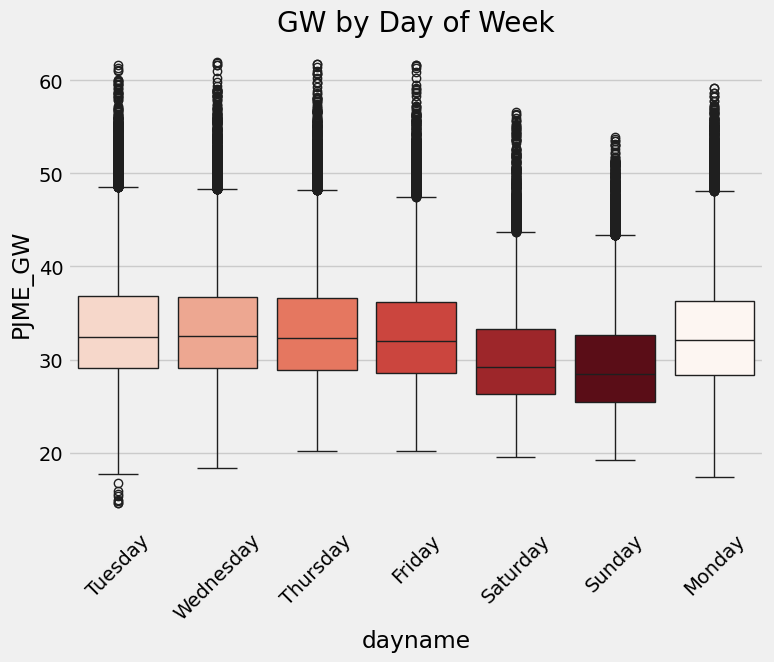

In [120]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x='dayname', y=f'{provider}_GW',
            hue='dayofweek', palette='Reds', legend=False)
ax.set_title('GW by Day of Week')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.show()


# Create our Model

In [121]:
train = create_features(train)
test = create_features(test)

FEATURES = ['dayofyear', 'hour', 'dayofweek',
            'quarter', 'month', 'year',
            ]
TARGET = f'{provider}_GW'

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [122]:
reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',
                       n_estimators=1000,
                       early_stopping_rounds=50,
                       objective='reg:linear',
                       max_depth=3,
                       learning_rate=0.01)
reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100)

[0]	validation_0-rmse:32.15455	validation_1-rmse:30.95265


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [18:48:11] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:12.43259	validation_1-rmse:11.34316
[200]	validation_0-rmse:5.80297	validation_1-rmse:5.14390
[300]	validation_0-rmse:3.92674	validation_1-rmse:3.93032
[400]	validation_0-rmse:3.46787	validation_1-rmse:3.86815
[420]	validation_0-rmse:3.42482	validation_1-rmse:3.87359


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

# Feature Importance

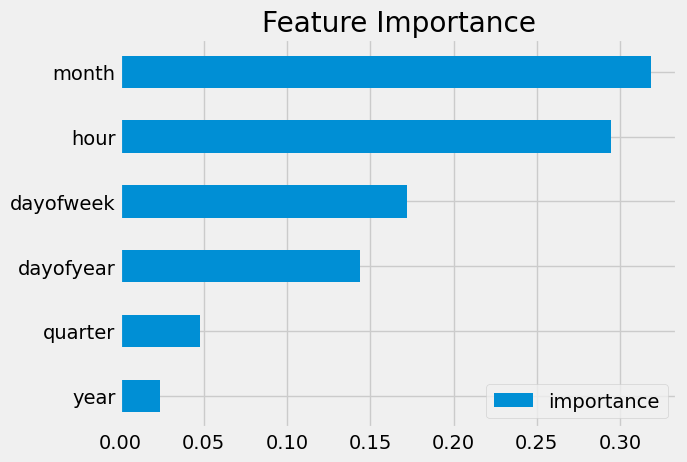

In [123]:
fi = pd.DataFrame(data=reg.feature_importances_,
             index=reg.feature_names_in_,
             columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()

# Forecast on Test

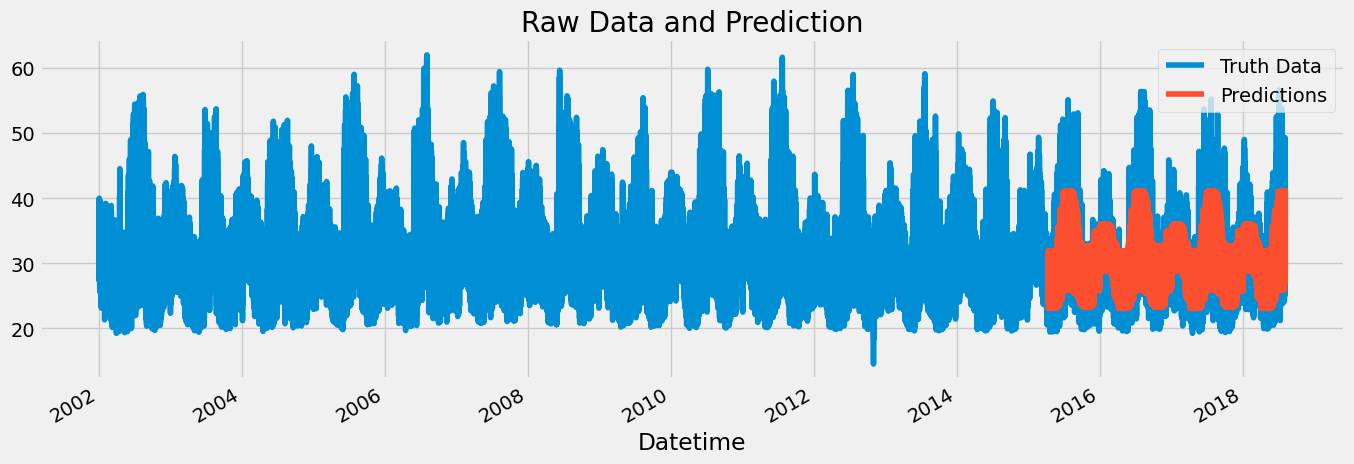

In [124]:
test['prediction'] = reg.predict(X_test)
if 'prediction' in df.columns:
    df = df.drop(columns=['prediction'])
df = df.merge(test[['prediction']], how='left', left_index=True, right_index=True)
ax = df[[f'{provider}_GW']].plot(figsize=(15, 5))
df['prediction'].plot(ax=ax, style='-')
plt.legend(['Truth Data', 'Predictions'])
ax.set_title('Raw Data and Prediction')
# plt.xlim(['2016-10-12', '2016-10-26'])
plt.show()

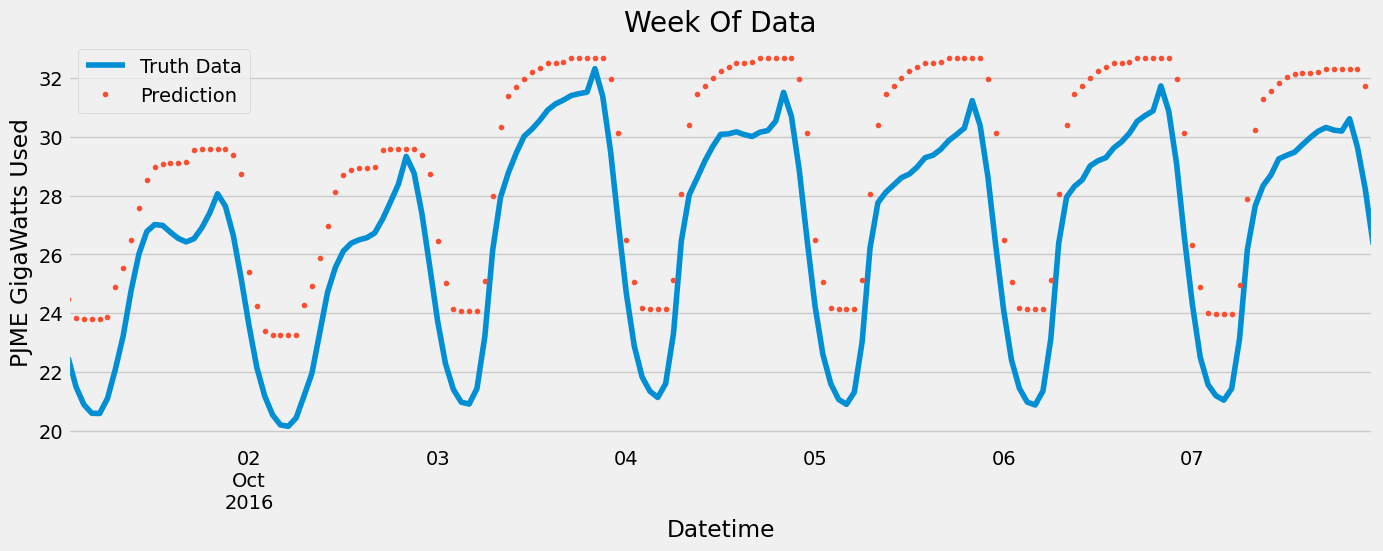

In [125]:
ax = df.loc[(df.index > '10-01-2016') & (df.index < '10-08-2016')][f'{provider}_GW'] \
    .plot(figsize=(15, 5), title='Week Of Data', ylabel=f'{provider} GigaWatts Used')
df.loc[(df.index > '10-01-2016') & (df.index < '10-08-2016')]['prediction'] \
    .plot(style='.')
plt.legend(['Truth Data','Prediction'])
plt.show()

Prediction looks good on a long-term scale, but is off on a short term scale.The prediction within a day does not increase in usage toward the nights. What features can cause this variation?

Possible feature ideas:
- Holidays
- duration of day: morning, afternoon, evening, night
- temperature
- wind
- pressure
- humidity

# Score

In [126]:
score = np.sqrt(mean_squared_error(test[f'{provider}_GW'], test['prediction']))
print(f'RMSE Score on Test set: {score:0.2f}')

RMSE Score on Test set: 3.86


# Calculate Error

In [127]:
test['error'] = np.abs(test[TARGET] - test['prediction'])
test['date'] = test.index.date
print('Worst prediction hours')
test.groupby(['hour'])[['error', 'prediction', f'{provider}_GW']].mean(1).sort_values('error',
                                                                    ascending=False).head(5)

Worst prediction hours


,error,prediction,PJME_GW
hour,,,
16,4.094565,34.270226,34.194142
17,4.013052,34.452332,34.832743
15,3.957543,34.248295,33.884512
18,3.807052,34.523552,35.601045
14,3.703128,34.250267,33.671162


In [128]:
test['day'] = test.index.date
print('Worst prediction dates:')
display(test.groupby(['date'])[['error', 'prediction', f'{provider}_GW']].mean(1).sort_values('error',
                                                                    ascending=False).head(5))
print('\n\nBest prediction dates:')
display(test.groupby(['date'])[['error', 'prediction', f'{provider}_GW']].mean(1).sort_values('error',
                                                                    ascending=True).head(5))

Worst prediction dates:


,error,prediction,PJME_GW
date,,,
2016-08-13,12.889964,32.295872,45.185833
2016-08-14,12.482307,31.945028,44.427333
2018-01-06,11.708525,31.857225,43.565750
2016-09-10,11.312255,29.683912,40.996167
2016-09-09,10.814452,33.022507,43.836958




Best prediction dates:


,error,prediction,PJME_GW
date,,,
2018-05-16,0.635348,29.502502,29.049833
2017-04-07,0.688471,29.171082,28.840250
2018-04-17,0.703141,29.502502,29.924833
2016-03-20,0.712964,27.504211,27.989417
2016-03-04,0.732266,33.032059,33.230167


In [129]:
import holidays
def more_features(df):
    """
    Create time series features based on time series index.
    Hour, dayofweek, quarter, month, year, dayofyear, dayofmonth, weekofyear.
    """
    df = df.copy()

    country_holidays = holidays.country_holidays('US', years=df.year.unique())
    holiday_list = pd.to_datetime(list(country_holidays.keys()))
    df['is_holiday'] = df.index.normalize().isin(holiday_list).astype(int)

    for fname, attr in zip(['temperature.csv', 'humidity.csv', 'pressure.csv', 'wind_speed.csv'],
                           ['temp', 'humidity', 'pressure', 'wind_speed']):
      df_temp = pd.read_csv(f'./drive/MyDrive/data_science_projects/electricity_usage_prediction/{fname}')
      df_temp = df_temp.loc[:,['datetime',
                                'Philadelphia',
                                'Pittsburgh',
                                'Chicago',
                                'Indianapolis',
                                'Detroit',
                                'Nashville',
                                'Charlotte']]
      df_temp.index = pd.to_datetime(df_temp['datetime'])
      df_temp = df_temp.drop(columns=['datetime'])
      df_temp = df_temp.rename(columns={'Philadelphia': f'{attr}_Philadelphia',
                                        'Pittsburgh': f'{attr}_Pittsburgh',
                                        'Chicago': f'{attr}_Chicago',
                                        'Indianapolis': f'{attr}_Indianapolis',
                                        'Detroit': f'{attr}_Detroit',
                                        'Nashville': f'{attr}_Nashville',
                                        'Charlotte': f'{attr}_Charlotte'})
      df = df.join(df_temp)
    return df

df = more_features(df)

In [137]:
df['temp_Philadelphia'].first_valid_index()#.plot(figsize=(15, 5), title='temp_Philadelphia')

Timestamp('2012-10-01 13:00:00')

In [140]:
start_date = df['pressure_Philadelphia'].first_valid_index()

Timestamp('2012-10-01 13:00:00')